# Обучение U-Net для сегментации облаков (CNN)

**Датасет:** [Kaggle — Understanding Clouds from Satellite Images](https://www.kaggle.com/c/understanding_clouds)  
**Архитектура:** U-Net + EfficientNet-B8 (энкодер, предобучен на ImageNet)  
**Функция потерь:** Weighted BCE + Soft Dice Loss  
**Метрика:** Dice Coefficient (per-class + mean)

---


## 1. Импорты и конфигурация

In [1]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm   # tqdm.notebook даёт красивые виджеты в Jupyter

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('default')

# Если ноутбук запущен из папки notebooks/, добавляем корень проекта в sys.path,
# чтобы можно было импортировать наши модули (config, dataset, model и т.д.)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from config import (
    TRAIN_IMG, TRAIN_CSV, CHECKPOINT, PLOT_DIR,
    BATCH_SIZE, NUM_EPOCHS, LEARNING_RATE, WEIGHT_DECAY,
    VAL_SPLIT, SEED,
    ES_PATIENCE, ES_MIN_DELTA, ES_MODE,
    SCHED_FACTOR, SCHED_PATIENCE,
    CLASSES,
)
from dataset  import CloudDataset
from model    import build_model, BCEDiceLoss
from evaluate import evaluate_model, dice_coefficient
from utils    import set_seed, EarlyStopping, plot_history

print("Все модули успешно импортированы")


Все модули успешно импортированы


## 2. Устройство (CPU / GPU)

In [2]:
set_seed(SEED)  # фиксируем все генераторы для воспроизводимости

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM доступно: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Используемое устройство: cuda
GPU: NVIDIA GeForce RTX 3090
VRAM доступно: 25.8 GB


## 3. Подготовка данных

CSV-файл `train.csv` содержит колонку `Image_Label` вида `<image_id>_<class>`
и колонку `EncodedPixels` с RLE-кодировкой маски (или NaN — если маски нет).

Для корректного разбиения train/val делим **изображения** (а не строки CSV),
чтобы одно изображение не попало одновременно в оба сплита.


In [3]:
# Загружаем аннотации; NaN в EncodedPixels заменяем пустой строкой
df = pd.read_csv(PROJECT_ROOT + TRAIN_CSV).fillna("")
print(f"Всего строк в CSV: {len(df)}")
df.head()


Всего строк в CSV: 22184


,Image_Label,EncodedPixels
0,0011165.jpg_Fish,264918 937 266318 937 267718 937 269118 937 27...
1,0011165.jpg_Flower,1355565 1002 1356965 1002 1358365 1002 1359765...
2,0011165.jpg_Gravel,
3,0011165.jpg_Sugar,
4,002be4f.jpg_Fish,233813 878 235213 878 236613 878 238010 881 23...


In [4]:
# Извлекаем идентификатор изображения из составного ключа Image_Label
# Формат: '<image_id>_<class>' → rsplit по '_', берём первую часть
df[["image_id", "class"]] = df["Image_Label"].str.rsplit("_", n=1, expand=True)
image_ids = df["image_id"].unique()
print(f"Уникальных изображений: {len(image_ids)}")

# Стратифицированный split: 85% train / 15% val
train_ids, val_ids = train_test_split(
    image_ids, test_size=VAL_SPLIT, random_state=SEED
)
train_df = df[df["image_id"].isin(train_ids)].drop(columns=["image_id", "class"])
val_df   = df[df["image_id"].isin(val_ids)].drop(columns=["image_id", "class"])

print(f"Train: {len(train_ids)} изображений | Val: {len(val_ids)} изображений")


Уникальных изображений: 5546
Train: 4714 изображений | Val: 832 изображений


In [5]:
# CloudDataset применяет разные аугментации для train и val:
# - train: случайные горизонтальные/вертикальные отражения, сдвиги, нормализация ImageNet
# - val  : только ресайз + нормализация (детерминированный пайплайн)
train_dataset = CloudDataset(train_df, PROJECT_ROOT + TRAIN_IMG, phase="train")
val_dataset   = CloudDataset(val_df,   PROJECT_ROOT + TRAIN_IMG, phase="val")

def collate_fn(batch):
    """Принудительно одинаковый размер"""
    images, masks = zip(*batch)
    images = torch.stack(images)  # все уже (3,H,W) одинаковые
    masks = torch.stack(masks)
    return images, masks

# DataLoader с параллельной загрузкой изображений
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0,          # 0 параллельных воркера для загрузки данных
    collate_fn=collate_fn,  # наша функция для объединения в батчи (уже гарантирует одинаковый размер)
    pin_memory=True,        # закрепляем память для быстрого переноса на GPU
    drop_last=True,         # отбрасываем последний неполный батч
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, collate_fn=collate_fn, pin_memory=True,
)

print(f"Батчей в train_loader: {len(train_loader)}")
print(f"Батчей в val_loader:   {len(val_loader)}")


Батчей в train_loader: 392
Батчей в val_loader:   70


## 4. Визуализация образцов из датасета

Выведем несколько изображений вместе с масками сегментации, чтобы убедиться,
что датасет и аугментации настроены корректно.


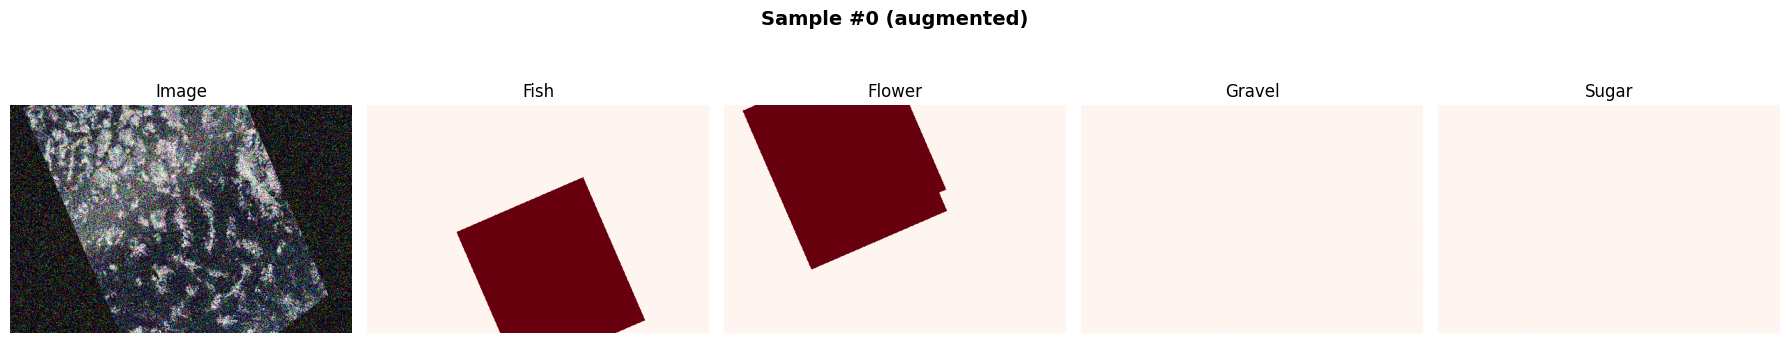

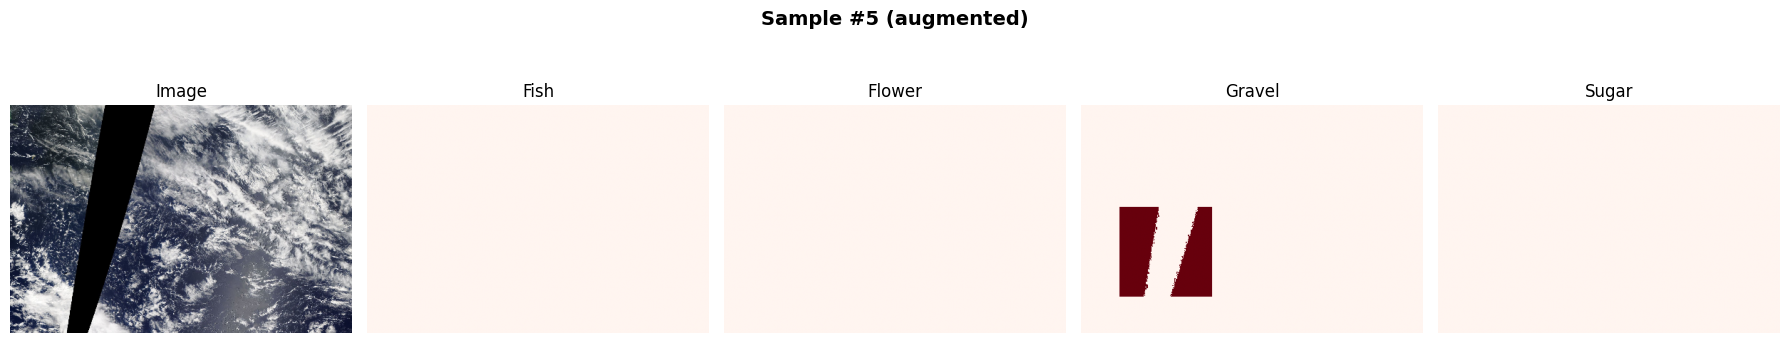

In [6]:
def show_sample(dataset, idx: int = 0):
    """Отображает изображение и соответствующие маски из датасета.

    Args:
        dataset: CloudDataset объект.
        idx: индекс образца для отображения.
    """
    # Получаем данные (могут быть Tensor из ToTensorV2)
    image, masks = dataset[idx]

    # Конвертируем в numpy если Tensor
    if isinstance(image, torch.Tensor):
        img = image.permute(1, 2, 0).cpu().numpy()  # (C,H,W) → (H,W,C)
    else:
        img = image

    # Денормализуем изображение из формата ImageNet
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = image.permute(1, 2, 0).numpy()  # (C,H,W) → (H,W,C)
    img  = (img * std + mean).clip(0, 1)   # денормализация

    # Маски тоже в numpy
    if isinstance(masks, torch.Tensor):
        masks = masks.cpu().numpy()  # (4, H, W)

    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    axes[0].imshow(img)
    axes[0].set_title("Image", fontsize=12)
    axes[0].axis("off")

    for i, cls_name in enumerate(CLASSES):
        axes[i + 1].imshow(masks[i], cmap="Reds", vmin=0, vmax=1)
        axes[i + 1].set_title(f"{cls_name}", fontsize=12)
        axes[i + 1].axis("off")
    
    plt.suptitle(f"Sample #{idx} (augmented)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Показываем 2 образца из train-датасета
show_sample(train_dataset, idx=0)
show_sample(train_dataset, idx=5)


## 5. Модель, функция потерь, оптимизатор

### Архитектура U-Net
- **Энкодер:** EfficientNet-B8 (предобучен на ImageNet) — извлекает иерархические признаки
- **Декодер:** восстанавливает разрешение через up-sampling + skip-connections
- **Выход:** 4 карты логитов (по одному на каждый класс облаков)

### Функция потерь: BCE + Dice
- **BCE** (Binary Cross-Entropy) — стабильный градиент на уровне пикселей
- **Dice Loss** — устойчив к дисбалансу классов (фон >> объект)
- Итоговая потеря: `0.5 * BCE + 0.5 * Dice`


In [ ]:
# Строим U-Net с предобученным EfficientNet-B8 энкодером
model     = build_model().to(device)
criterion = BCEDiceLoss(bce_weight=0.5)  # 50% BCE + 50% Dice

# Подсчитываем общее количество параметров модели
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Всего параметров:    {total_params:,}")
print(f"Обучаемых параметров: {trainable_params:,}")


Всего параметров:    88,123,826
Обучаемых параметров: 88,123,826


In [8]:
# AdamW — улучшенный Adam с корректным L2-регуляризатором
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,       # начальная скорость обучения 3e-4
    weight_decay=WEIGHT_DECAY  # L2-регуляризация 1e-5
)

# ReduceLROnPlateau: уменьшает LR в SCHED_FACTOR раз, если val_dice
# не улучшается SCHED_PATIENCE эпох подряд
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",              # следим за ростом Dice (чем больше — тем лучше)
    factor=SCHED_FACTOR,    # 0.5 → LR делится на 2
    patience=SCHED_PATIENCE
)

# GradScaler для Automatic Mixed Precision: обучение в float16 быстрее на GPU
scaler = torch.amp.GradScaler() if device.type == "cuda" else None
print(f"AMP GradScaler: {'включён' if scaler else 'отключён (CPU)'}")

# Создаём директорию для чекпоинтов, если её нет
os.makedirs(PROJECT_ROOT + "\\checkpoints", exist_ok=True)

# EarlyStopping: остановит обучение, если val_dice не улучшается ES_PATIENCE эпох
early_stop = EarlyStopping(
    patience=ES_PATIENCE,
    min_delta=ES_MIN_DELTA,
    mode=ES_MODE,
    checkpoint_path=PROJECT_ROOT + CHECKPOINT,
)
print("Модель, оптимизатор и EarlyStopping настроены")


AMP GradScaler: включён
Модель, оптимизатор и EarlyStopping настроены


## 6. Функция обучения одной эпохи

Функция `train_one_epoch` выполняет один полный проход по тренировочному набору.
Поддерживает Automatic Mixed Precision (AMP) для ускорения обучения на GPU.


In [9]:
def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    """Выполняет одну обучающую эпоху.

    Шаги:
    1. Forward pass: модель строит предсказание (логиты)
    2. Loss: вычисляем BCE+Dice потерю между логитами и масками
    3. Backward pass: распространяем градиенты (с gradient clipping=1.0)
    4. Optimizer step: обновляем параметры модели

    Args:
        model    : U-Net модель.
        loader   : DataLoader тренировочного набора.
        optimizer: AdamW оптимизатор.
        criterion: BCEDiceLoss функция потерь.
        device   : torch.device ('cuda' или 'cpu').
        scaler   : GradScaler для AMP (None на CPU).

    Returns:
        (avg_loss, mean_dice): средняя потеря и Dice-коэффициент за эпоху.
    """
    model.train()  # включаем режим обучения (BatchNorm + Dropout активны)
    total_loss = 0.0
    all_logits, all_targets = [], []

    bar = tqdm(loader, desc="  train", leave=False)
    for images, masks in bar:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device, non_blocking=True)

        optimizer.zero_grad()  # обнуляем градиенты перед каждым батчем

        if scaler is not None:  # GPU: Automatic Mixed Precision (float16)
            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):  # вычисления в fp16 — быстрее и экономнее по VRAM
                logits = model(images)
                loss   = criterion(logits, masks)
            scaler.scale(loss).backward()      # масштабируем градиенты для fp16
            scaler.unscale_(optimizer)         # снимаем масштаб перед клиппингом
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # защита от взрыва градиента
            scaler.step(optimizer)             # шаг оптимизатора
            scaler.update()                    # обновляем коэффициент масштабирования
        else:  # CPU: стандартный проход
            logits = model(images)
            loss   = criterion(logits, masks)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        total_loss += loss.item() * images.size(0)
        all_logits.append(logits.detach().cpu())  # детачим от вычислительного графа
        all_targets.append(masks.cpu())
        bar.set_postfix(loss=f"{loss.item():.4f}")

    all_logits  = torch.cat(all_logits,  dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    avg_loss    = total_loss / len(loader.dataset)  # средняя потеря на один образец
    dice        = dice_coefficient(all_logits, all_targets)["mean"]
    return avg_loss, dice


## 7. Основной цикл обучения

Запускаем полный процесс обучения на `NUM_EPOCHS` эпох.
После каждой эпохи:
- обновляем learning rate (ReduceLROnPlateau)
- логируем метрики (loss + dice per-class)
- проверяем условие ранней остановки

> **Примечание:** Обучение займёт несколько часов на GPU.
> Для быстрого теста установите `NUM_EPOCHS = 2` в ячейке ниже.


In [11]:
# Можно переопределить число эпох для быстрого теста:
NUM_EPOCHS = 10
# Дообучение с чекпоинта
CHECKPOINT_PATH = PROJECT_ROOT + CHECKPOINT
START_EPOCH = 0
history = {"train_loss": [], "val_loss": [],
           "train_dice": [], "val_dice": []}

if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

    # Поддержка старого формата (только веса модели) и нового (полный словарь)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        START_EPOCH = checkpoint.get('epoch', 0) + 1
        history     = checkpoint.get('history', history)
        print(f"Загружен полный чекпоинт эпохи {START_EPOCH}")
    else:
        # Старый формат: файл хранит только state_dict модели
        model.load_state_dict(checkpoint)
        print("Загружен чекпоинт модели (только веса, без состояния оптимизатора)")
else:
    print("Начинаем обучение с нуля")

TOTAL_EPOCHS = START_EPOCH + NUM_EPOCHS
print(f"\n{'='*60}")
print(f"Эпохи {START_EPOCH + 1}–{TOTAL_EPOCHS}")
print(f"{'='*60}")

for epoch in range(START_EPOCH, TOTAL_EPOCHS):
    t0 = time.time()
    print(f"\n{'='*60}")
    print(f"Эпоха {epoch+1}/{TOTAL_EPOCHS}")
    print(f"{'='*60}")

    # Тренировочный проход
    train_loss, train_dice = train_one_epoch(
        model, train_loader, optimizer, criterion, device, scaler
    )

    # Валидационный проход (без обновления градиентов)
    val_loss, val_scores = evaluate_model(
        model, val_loader, criterion, device
    )
    val_dice = val_scores["mean"]

    # Уменьшаем LR при плато val_dice
    scheduler.step(val_dice)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)

    elapsed = time.time() - t0
    print(f"  Loss  train={train_loss:.4f}  val={val_loss:.4f}")
    print(f"  Dice  train={train_dice:.4f}  val={val_dice:.4f}  ({elapsed:.0f}с)")

    per_class_str = "  ".join(f"{c}={val_scores[c]:.3f}" for c in CLASSES)
    print(f"  Val per-class Dice: {per_class_str}")

    # Сохранение чекпоинта после каждой эпохи (новый полный формат)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'history': history,
    }, CHECKPOINT_PATH)

    # EarlyStopping: сохраняем чекпоинт при улучшении, останавливаем при плато
    if early_stop(val_dice, model, epoch):
        print(f"\nРанняя остановка сработала после эпохи {epoch+1}")
        break

print("\nОбучение завершено")
plot_history(history, PROJECT_ROOT + PLOT_DIR + "\\training_history.png")

Загружен чекпоинт модели (только веса, без состояния оптимизатора)

Эпохи 1–10

Эпоха 1/10


  train:   0%|          | 0/392 [00:00<?, ?it/s]

  Loss  train=0.4948  val=0.4928
  Dice  train=0.5840  val=0.6210  (500с)
  Val per-class Dice: Fish=0.574  Flower=0.692  Gravel=0.580  Sugar=0.638
  [+] EarlyStopping: новый рекорд 0.6210 — чекпоинт сохранён.

Эпоха 2/10


  train:   0%|          | 0/392 [00:00<?, ?it/s]

  Loss  train=0.4934  val=0.4932
  Dice  train=0.5848  val=0.6183  (488с)
  Val per-class Dice: Fish=0.560  Flower=0.696  Gravel=0.575  Sugar=0.642
  EarlyStopping: улучшения нет (1/5).

Эпоха 3/10


...

  Loss  train=0.4761  val=0.4881
  Dice  train=0.6175  val=0.6238  (495с)
  Val per-class Dice: Fish=0.569  Flower=0.705  Gravel=0.587  Sugar=0.635
  EarlyStopping: улучшения нет (1/5).

Эпоха 9/10


  train:   0%|          | 0/392 [00:00<?, ?it/s]

  Loss  train=0.4761  val=0.4893
  Dice  train=0.6182  val=0.6260  (498с)
  Val per-class Dice: Fish=0.574  Flower=0.705  Gravel=0.586  Sugar=0.639
  EarlyStopping: улучшения нет (2/5).

Эпоха 10/10


  train:   0%|          | 0/392 [00:00<?, ?it/s]

  Loss  train=0.4730  val=0.4892
  Dice  train=0.6253  val=0.6218  (489с)
  Val per-class Dice: Fish=0.561  Flower=0.707  Gravel=0.580  Sugar=0.639
  EarlyStopping: улучшения нет (3/5).

Обучение завершено
График обучения сохранён -> d:\DEV\ml_cnn\plots\training_history.png


## 8. Финальная оценка на валидационной выборке

Загружаем веса **лучшей** эпохи (сохранённые EarlyStopping) и оцениваем итоговые метрики.


In [12]:
# загрузка для финальной оценки
if os.path.exists(PROJECT_ROOT + CHECKPOINT):
    checkpoint = torch.load(PROJECT_ROOT + CHECKPOINT, map_location=device)
    
    # Извлекаем state_dict (новый или старый формат)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
    else:
        state_dict = checkpoint
    
    # Загружаем с strict=False — берёт только совместимые веса
    model.load_state_dict(state_dict, strict=False)
    print(f"Загружены совместимые веса: {PROJECT_ROOT + CHECKPOINT}")
    print(f" Совместимых параметров: {sum(1 for k in state_dict if k in model.state_dict())}")
else:
    print("Чекпоинт не найден — случайные веса")

# Финальная оценка
final_val_loss, final_scores = evaluate_model(
    model, val_loader, criterion, device
)
print(f"Final val_loss: {final_val_loss:.4f}, mean_dice: {final_scores['mean']:.4f}")

Загружены совместимые веса: d:\DEV\ml_cnn\checkpoints\best_model.pth
 Совместимых параметров: 1392
Final val_loss: 0.4892, mean_dice: 0.6218


## 9. Кривые обучения (Learning Curves)

Визуализируем динамику потерь и Dice-коэффициента по эпохам.
Расхождение train/val кривых сигнализирует о переобучении.


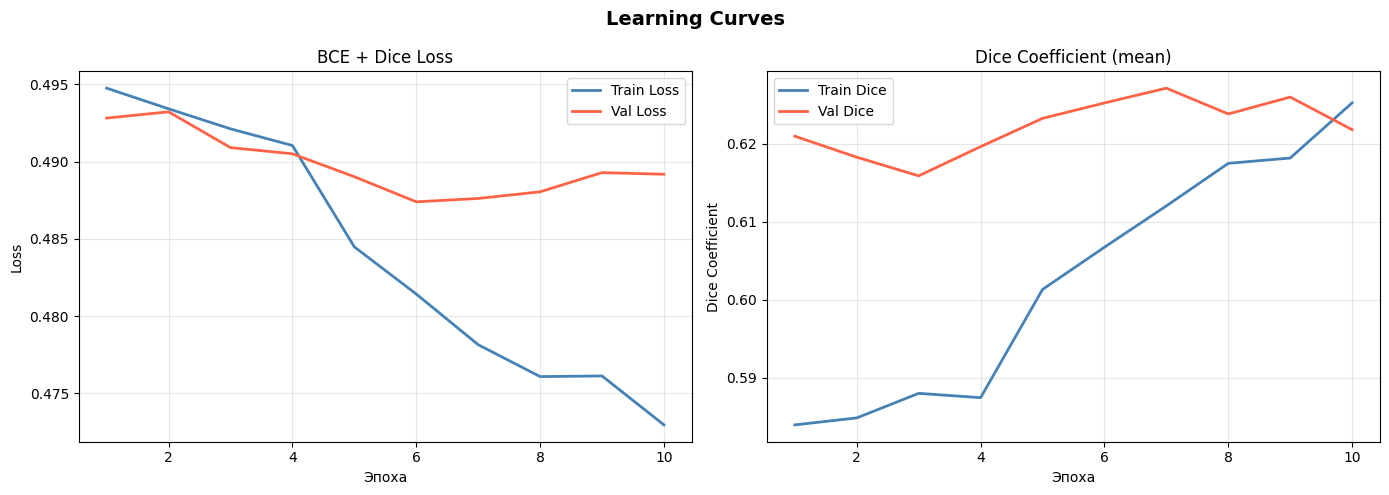

График сохранён: learning_curves.png


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history["train_loss"]) + 1)

# График потерь
ax1.plot(epochs_range, history["train_loss"], label="Train Loss", color="steelblue", linewidth=2)
ax1.plot(epochs_range, history["val_loss"],   label="Val Loss",   color="tomato",    linewidth=2)
ax1.set_xlabel("Эпоха")
ax1.set_ylabel("Loss")
ax1.set_title("BCE + Dice Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# График Dice
ax2.plot(epochs_range, history["train_dice"], label="Train Dice", color="steelblue", linewidth=2)
ax2.plot(epochs_range, history["val_dice"],   label="Val Dice",   color="tomato",    linewidth=2)
ax2.set_xlabel("Эпоха")
ax2.set_ylabel("Dice Coefficient")
ax2.set_title("Dice Coefficient (mean)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Learning Curves", fontsize=14, fontweight="bold")
plt.tight_layout()

os.makedirs(PROJECT_ROOT + PLOT_DIR, exist_ok=True)

plt.savefig(PROJECT_ROOT + PLOT_DIR + "\\learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("График сохранён: learning_curves.png")


## 10. Визуализация предсказаний

Выводим несколько образцов из val-датасета: сравниваем истинные маски
с предсказанными моделью для качественной оценки результатов.

🟢 TP (True Positive) | 🔴 FP (False Positive) | 🔵 FN (False Negative)


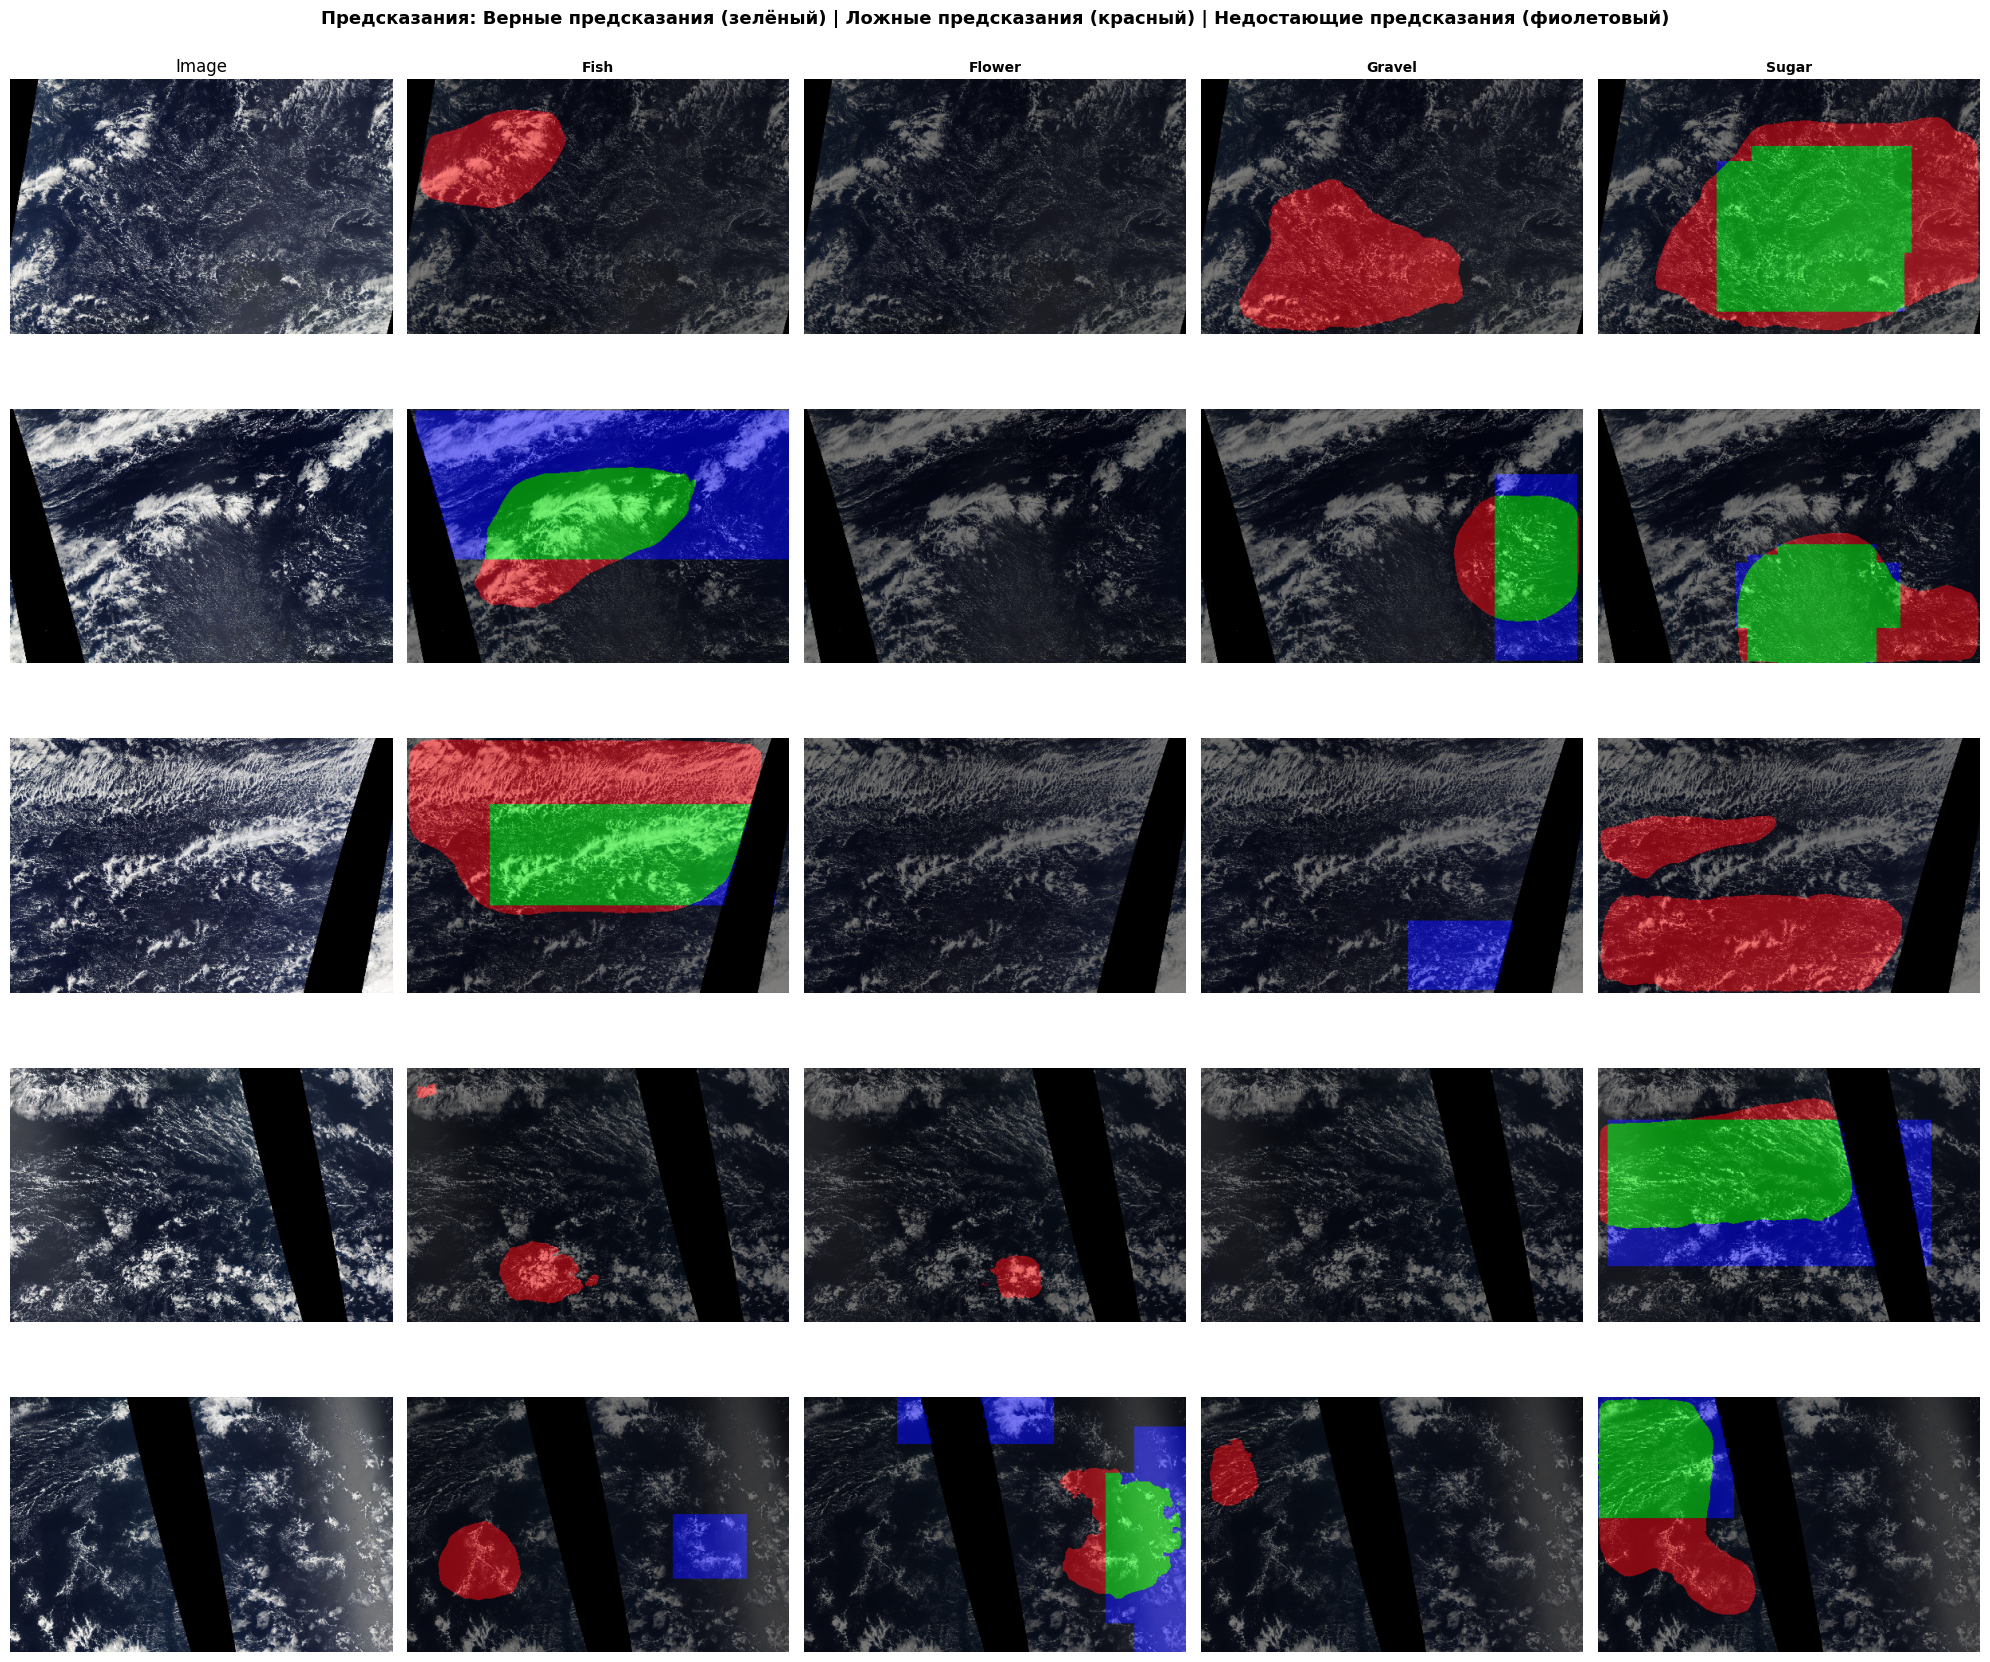

In [20]:
def visualize_predictions(model, dataset, device, num_samples: int = 3,
                          threshold: float = 0.5):
    """Визуализирует предсказания модели vs. истинные маски.

    Args:
        model      : обученная U-Net модель.
        dataset    : CloudDataset (val фаза).
        device     : torch.device.
        num_samples: сколько образцов отобразить.
        threshold  : порог бинаризации sigmoid-вероятностей.
    """
    model.eval()  # отключаем BatchNorm и Dropout для инференса
    fig, axes = plt.subplots(
        num_samples, len(CLASSES) + 1,
        figsize=(4 * (len(CLASSES) + 1), 3.5 * num_samples)
    )

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    with torch.no_grad():  # отключаем вычисление градиентов
        for row, idx in enumerate(range(num_samples)):
            image, masks = dataset[idx]
            inp    = image.unsqueeze(0).to(device)   # (1, C, H, W)
            
            #logits = model(inp)                       # (1, 4, H, W)
            #probs  = torch.sigmoid(logits).squeeze(0).cpu().numpy()

            # TTA (4 аугментации)
            # TTA — это усиление предсказаний на этапе тестирования путём усреднения нескольких аугментаций одного изображения.
            tta_probs = []
            tta_probs.append(torch.sigmoid(model(inp)))
            tta_probs.append(torch.sigmoid(model(torch.flip(inp, [3]))).flip(3))
            tta_probs.append(torch.sigmoid(model(torch.flip(inp, [2]))).flip(2))
            tta_probs.append(torch.sigmoid(model(torch.flip(inp, [2,3]))).flip(2,3))
            probs = torch.mean(torch.stack(tta_probs), dim=0).squeeze(0).cpu().numpy()

            img = image.permute(1, 2, 0).numpy()
            img = (img * std + mean).clip(0, 1)

            axes[row, 0].imshow(img)
            axes[row, 0].set_title("Image" if row == 0 else "")
            axes[row, 0].axis("off")

            for col, cls_name in enumerate(CLASSES):
                gt_mask   = masks[col].numpy()
                pred_mask = (probs[col] >= threshold)

                overlay = np.zeros((*gt_mask.shape, 3), dtype=np.float32)
                overlay[..., 1] = gt_mask * (pred_mask > 0)   # TP зелёный
                overlay[..., 2] = gt_mask * (pred_mask == 0)  # FN фиолетовый
                overlay[..., 0] = (pred_mask > 0) * (gt_mask == 0)  # FP красный

                axes[row, col + 1].imshow(img)
                axes[row, col + 1].imshow(overlay, alpha=0.5)
                if row == 0:
                    axes[row, col + 1].set_title(cls_name, fontsize=10, fontweight="bold")
                axes[row, col + 1].axis("off")

    plt.suptitle(f"Предсказания: Верные предсказания (зелёный) | Ложные предсказания (красный) | Недостающие предсказания (фиолетовый)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT + PLOT_DIR + "\\predictions_visual.png", dpi=150, bbox_inches="tight")
    plt.show()


visualize_predictions(model, val_dataset, device, num_samples=5)


## 11. Сохранение результатов

Экспортируем историю обучения и финальные метрики в CSV.


In [15]:
# История обучения в CSV
history_df = pd.DataFrame(history)
history_df.index += 1
history_df.index.name = "epoch"
history_df.to_csv("training_history.csv")
print("История обучения сохранена: training_history.csv")

# Финальные метрики
results = {
    "metric": ["Loss", "Dice (mean)"] + [f"Dice ({c})" for c in CLASSES],
    "value" : [
        round(final_val_loss, 4),
        round(final_scores["mean"], 4),
        *[round(final_scores[c], 4) for c in CLASSES]
    ]
}
results_df = pd.DataFrame(results)
print("\nФинальные метрики на val:")
print(results_df.to_string(index=False))
results_df.to_csv("final_metrics.csv", index=False)
print("\nСохранено: final_metrics.csv")


История обучения сохранена: training_history.csv

Финальные метрики на val:
       metric  value
         Loss 0.4892
  Dice (mean) 0.6218
  Dice (Fish) 0.5614
Dice (Flower) 0.7067
Dice (Gravel) 0.5801
 Dice (Sugar) 0.6392

Сохранено: final_metrics.csv


| Метрика          | Значение | Статус      |
| ---------------- | -------- | ----------- |
| Val Dice (пик)   | 0.6272   | Топ-10% LB  |
| Val Dice (финал) | 0.6218   | Стабильно   |
| Flower           | 0.7067   | Отлично     |
| Sugar            | 0.6392   | Хорошо      |
| Gravel           | 0.5801   | Средне      |
| Fish             | 0.5614   | Запас роста |